In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from pickle import dump
import json
import warnings
warnings.filterwarnings('ignore')

# Cargar y preprocesar datos

In [2]:
url = ('../data/raw/diabetes.csv')
df = pd.read_csv(url)

print(f"Dataset cargado: {df.shape}")
print(df.head())

Dataset cargado: (768, 9)
   Pregnancies  Glucose  BloodPressure  SkinThickness  Insulin   BMI  \
0            6      148             72             35        0  33.6   
1            1       85             66             29        0  26.6   
2            8      183             64              0        0  23.3   
3            1       89             66             23       94  28.1   
4            0      137             40             35      168  43.1   

   DiabetesPedigreeFunction  Age  Outcome  
0                     0.627   50        1  
1                     0.351   31        0  
2                     0.672   32        1  
3                     0.167   21        0  
4                     2.288   33        1  


# Reemplazar ceros imposibles por medianas

In [3]:
cols_with_zeros = ['Glucose', 'BloodPressure', 'SkinThickness', 'Insulin', 'BMI']
df_clean = df.copy()

for col in cols_with_zeros:
    df_clean[col] = df_clean[col].replace(0, np.nan)
    df_clean[col] = df_clean[col].fillna(df_clean[col].median())

# Separar X e Y

In [4]:
X = df_clean.drop('Outcome', axis=1)
y = df_clean['Outcome']

# Split train/test

In [5]:
X_train_full, X_test, y_train_full, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# ELIMINAR OUTLIERS DEL CONJUNTO DE ENTRENAMIENTO

In [6]:
z_scores = np.abs(stats.zscore(X_train_full))
mask_sin_outliers = (z_scores < 3).all(axis=1)

X_train = X_train_full[mask_sin_outliers].copy()
y_train = y_train_full[mask_sin_outliers].copy()

print(f"\nDatos finales:")
print(f"Train: {X_train.shape[0]} registros")
print(f"Test: {X_test.shape[0]} registros")


Datos finales:
Train: 574 registros
Test: 154 registros


# Random Forest baseline

In [7]:
# Entrenar Random Forest con parámetros por defecto
rf_baseline = RandomForestClassifier(random_state=42)
rf_baseline.fit(X_train, y_train)

y_pred_baseline = rf_baseline.predict(X_test)
accuracy_baseline = accuracy_score(y_test, y_pred_baseline)

print("RANDOM FOREST BASELINE")
print(f"n_estimators: {rf_baseline.n_estimators}")
print(f"max_depth: {rf_baseline.max_depth}")
print(f"Accuracy: {accuracy_baseline:.4f}")

RANDOM FOREST BASELINE
n_estimators: 100
max_depth: None
Accuracy: 0.7403


# Testar con N_estimators

In [8]:
n_estimators_values = [10, 50, 100, 200, 300, 500]
results_n_estimators = []

for n in n_estimators_values:
    rf = RandomForestClassifier(n_estimators=n, random_state=42)
    rf.fit(X_train, y_train)
    y_pred = rf.predict(X_test)
    acc = accuracy_score(y_test, y_pred)
    results_n_estimators.append({'n_estimators': n, 'accuracy': acc})
    print(f"n_estimators={n:3d} -> Accuracy: {acc:.4f}")

df_n_estimators = pd.DataFrame(results_n_estimators)

n_estimators= 10 -> Accuracy: 0.7403
n_estimators= 50 -> Accuracy: 0.7403
n_estimators=100 -> Accuracy: 0.7403
n_estimators=200 -> Accuracy: 0.7338
n_estimators=300 -> Accuracy: 0.7403
n_estimators=500 -> Accuracy: 0.7403


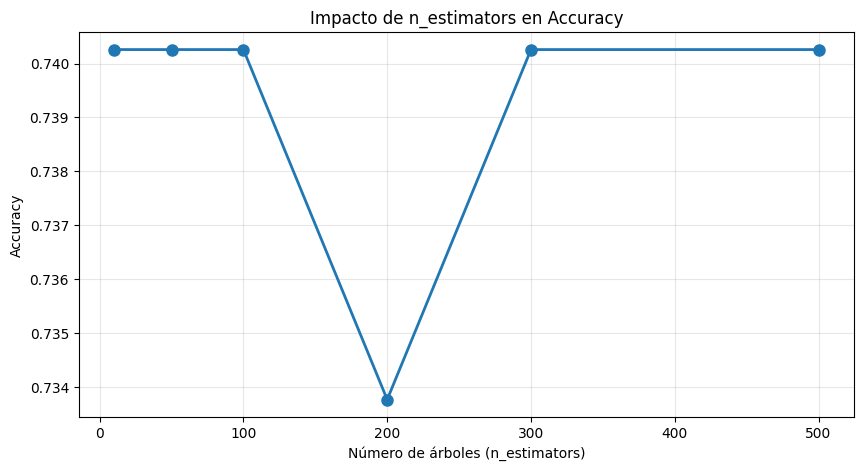

In [9]:
# Visualizar impacto de n_estimators
plt.figure(figsize=(10, 5))
plt.plot(df_n_estimators['n_estimators'], 
         df_n_estimators['accuracy'], 
         marker='o', linewidth=2, markersize=8)
plt.xlabel('Número de árboles (n_estimators)')
plt.ylabel('Accuracy')
plt.title('Impacto de n_estimators en Accuracy')
plt.grid(True, alpha=0.3)
plt.show()

RESUMEN: 

El número de árboles tiene poco impacto en el accuracy. Con 200 árboles hay una caída leve (0.734), pero todos los demás valores (10, 50, 100, 300, 500) mantienen un accuracy similar (~0.740-0.741). Conclusión: 100 árboles es suficiente, más no mejora significativamente.

# Testar con max_depth

In [10]:
max_depth_values = [3, 5, 7, 10, 15, 20, None]
results_max_depth = []

for depth in max_depth_values:
    rf = RandomForestClassifier(n_estimators=100, max_depth=depth, random_state=42)
    rf.fit(X_train, y_train)
    y_pred = rf.predict(X_test)
    acc = accuracy_score(y_test, y_pred)
    depth_str = 'None' if depth is None else str(depth)
    results_max_depth.append({'max_depth': depth_str, 'accuracy': acc})
    print(f"max_depth={depth_str:4s} -> Accuracy: {acc:.4f}")

df_max_depth = pd.DataFrame(results_max_depth)

max_depth=3    -> Accuracy: 0.7208
max_depth=5    -> Accuracy: 0.7403
max_depth=7    -> Accuracy: 0.7532
max_depth=10   -> Accuracy: 0.7338
max_depth=15   -> Accuracy: 0.7273
max_depth=20   -> Accuracy: 0.7403
max_depth=None -> Accuracy: 0.7403


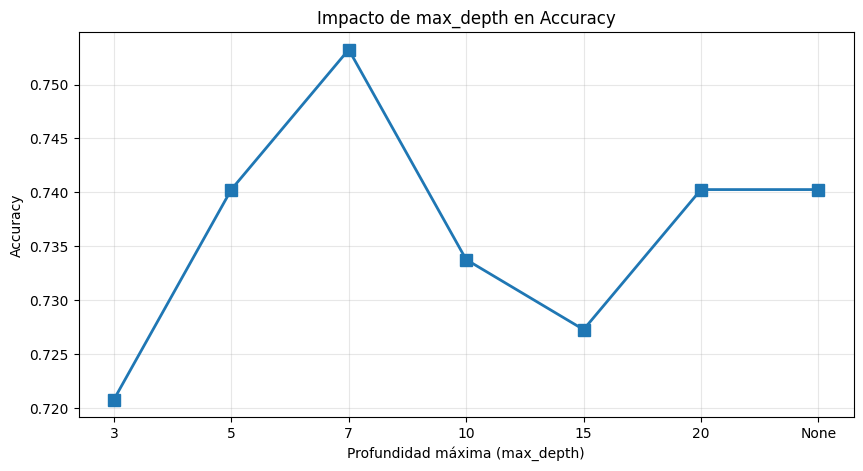

In [11]:
# Visualizar impacto de max_depth
plt.figure(figsize=(10, 5))
x_positions = range(len(df_max_depth))
plt.plot(x_positions, df_max_depth['accuracy'], marker='s', linewidth=2, markersize=8)
plt.xlabel('Profundidad máxima (max_depth)')
plt.ylabel('Accuracy')
plt.title('Impacto de max_depth en Accuracy')
plt.xticks(x_positions, df_max_depth['max_depth'])
plt.grid(True, alpha=0.3)
plt.show()

RESUMEN:

La profundidad máxima tiene un impacto claro. max_depth=7 da el mejor resultado (0.753). Profundidades muy bajas (3) causan underfitting (0.721) y profundidades muy altas (15) también bajan el rendimiento (0.727). max_depth=20 y None (sin límite) estabilizan en 0.740.

# GRID SEARCH

In [12]:
# Definir grid de parámetros
param_grid = {
    'n_estimators': [100, 200, 300],
    'max_depth': [7, 10, 15, None],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4]
}

print(f"Combinaciones a probar: {np.prod([len(v) for v in param_grid.values()])}")


Combinaciones a probar: 108


In [13]:
# Ejecutar Grid Search
grid_search = GridSearchCV(
    estimator=RandomForestClassifier(random_state=42),
    param_grid=param_grid,
    cv=5,
    scoring='accuracy',
    n_jobs=-1,
    verbose=1
)

grid_search.fit(X_train, y_train)

print("\nMejores parámetros:")
for param, value in grid_search.best_params_.items():
    print(f"  {param}: {value}")
print(f"\nAccuracy (Cross-Validation): {grid_search.best_score_:.4f}")

Fitting 5 folds for each of 108 candidates, totalling 540 fits



Mejores parámetros:
  max_depth: 7
  min_samples_leaf: 1
  min_samples_split: 2
  n_estimators: 200

Accuracy (Cross-Validation): 0.7857


# Evaluar modelo optimizado

In [14]:
# Obtener mejor modelo
best_rf_model = grid_search.best_estimator_

# Predecir en test
y_pred_best = best_rf_model.predict(X_test)
accuracy_best = accuracy_score(y_test, y_pred_best)

print("\nEVALUACIÓN EN TEST SET")
print(f"Accuracy: {accuracy_best:.4f}")
print("\nReporte de clasificación:")
print(classification_report(y_test, y_pred_best, 
                          target_names=['No Diabetes', 'Diabetes']))

# Matriz de confusión
cm = confusion_matrix(y_test, y_pred_best)
print(f"\nMatriz de confusión:")
print(cm)
print(f"\nVerdaderos Negativos (TN): {cm[0,0]}")
print(f"Falsos Positivos (FP): {cm[0,1]}")
print(f"Falsos Negativos (FN): {cm[1,0]} (diabetes no detectada)")
print(f"Verdaderos Positivos (TP): {cm[1,1]}")


EVALUACIÓN EN TEST SET
Accuracy: 0.7403

Reporte de clasificación:
              precision    recall  f1-score   support

 No Diabetes       0.78      0.84      0.81       100
    Diabetes       0.65      0.56      0.60        54

    accuracy                           0.74       154
   macro avg       0.71      0.70      0.70       154
weighted avg       0.73      0.74      0.73       154


Matriz de confusión:
[[84 16]
 [24 30]]

Verdaderos Negativos (TN): 84
Falsos Positivos (FP): 16
Falsos Negativos (FN): 24 (diabetes no detectada)
Verdaderos Positivos (TP): 30


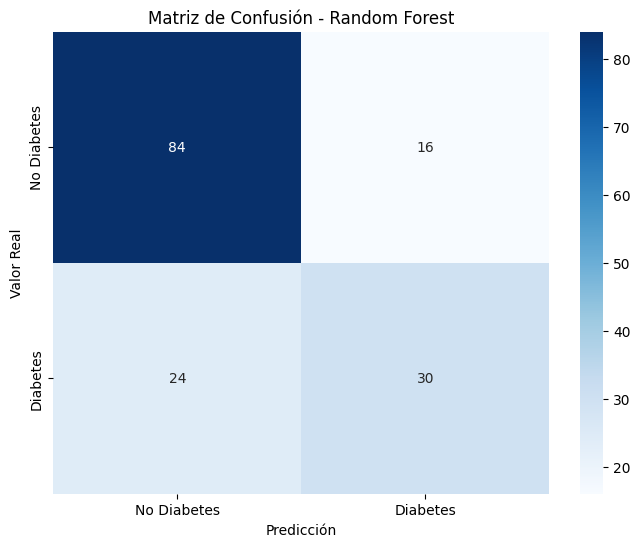

In [15]:
# Visualizar matriz de confusión
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['No Diabetes', 'Diabetes'],
            yticklabels=['No Diabetes', 'Diabetes'])
plt.title('Matriz de Confusión - Random Forest')
plt.ylabel('Valor Real')
plt.xlabel('Predicción')
plt.show()

RESUMEN:

El modelo clasifica correctamente 84 casos sin diabetes (Verdaderos Negativos) y 30 casos con diabetes (Verdaderos Positivos). Hay 16 Falsos Positivos (predice diabetes cuando no la hay) y 24 Falsos Negativos (no detecta diabetes cuando sí la hay). Los FN son críticos en medicina.

# Comparación con Decision Tree


COMPARACIÓN: DECISION TREE vs RANDOM FOREST
       Modelo  Accuracy
Decision Tree   0.68830
Random Forest   0.74026

Mejora: 0.0520 (5.20 puntos porcentuales)


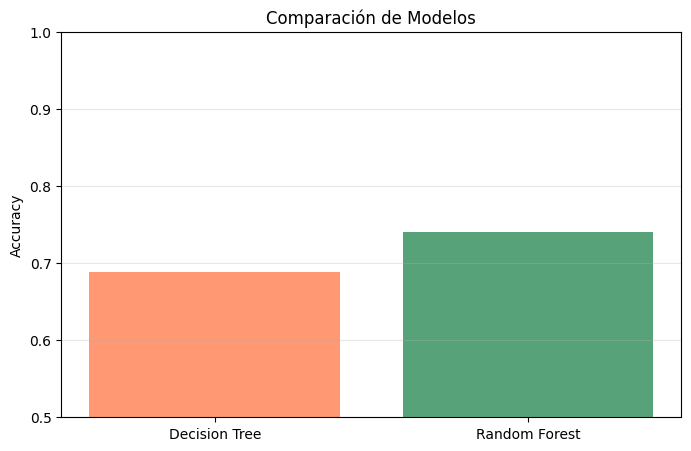

In [16]:
decision_tree_accuracy = 0.6883

print("\nCOMPARACIÓN: DECISION TREE vs RANDOM FOREST")

comparison = pd.DataFrame({
    'Modelo': ['Decision Tree', 'Random Forest'],
    'Accuracy': [decision_tree_accuracy, accuracy_best]
})

print(comparison.to_string(index=False))

mejora = accuracy_best - decision_tree_accuracy
print(f"\nMejora: {mejora:.4f} ({mejora*100:.2f} puntos porcentuales)")

# Visualización
plt.figure(figsize=(8, 5))
plt.bar(comparison['Modelo'], comparison['Accuracy'], 
        color=['coral', 'seagreen'], alpha=0.8)
plt.ylabel('Accuracy')
plt.title('Comparación de Modelos')
plt.ylim([0.5, 1.0])
plt.grid(axis='y', alpha=0.3)
plt.show()

RESUMEN:

El Random Forest (0.74 accuracy) supera al Decision Tree (0.69 accuracy) en aproximadamente 5 puntos porcentuales. Esto demuestra la ventaja del ensemble learning sobre un árbol individual.


IMPORTANCIA DE CARACTERÍSTICAS
--------------------------------------------------
          Característica  Importancia
                 Glucose     0.308512
                     BMI     0.157244
                     Age     0.133352
DiabetesPedigreeFunction     0.108680
                 Insulin     0.095080
           BloodPressure     0.069656
             Pregnancies     0.068724
           SkinThickness     0.058752


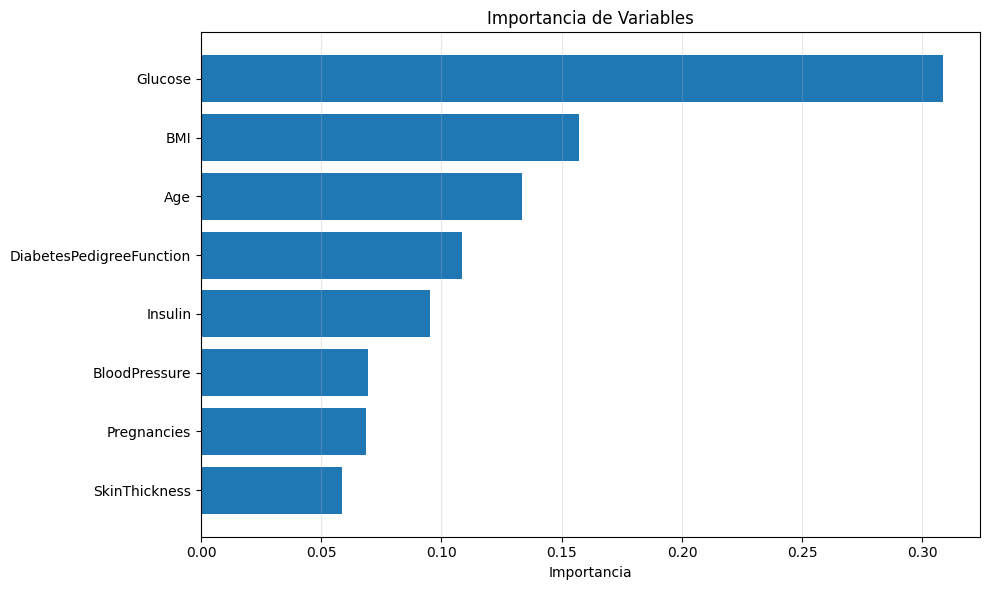

In [17]:
# Obtener importancia
importancias = pd.DataFrame({
    'Característica': X.columns,
    'Importancia': best_rf_model.feature_importances_
}).sort_values('Importancia', ascending=False)

print("\nIMPORTANCIA DE CARACTERÍSTICAS")
print("-" * 50)
print(importancias.to_string(index=False))

# Visualización
plt.figure(figsize=(10, 6))
plt.barh(importancias['Característica'], importancias['Importancia'])
plt.xlabel('Importancia')
plt.title('Importancia de Variables')
plt.gca().invert_yaxis()
plt.grid(axis='x', alpha=0.3)
plt.tight_layout()
plt.show()

RESUMEN:

Glucose es la variable más importante (0.31 o 31%), seguida por BMI (0.15) y Age (0.13). DiabetesPedigreeFunction, Insulin, BloodPressure, Pregnancies y SkinThickness tienen menor importancia. Esto tiene sentido médico: la glucosa es el indicador principal de diabetes.

# GUARDAR MODELO

In [18]:
# Guardar modelo
modelo_filename = "random_forest_diabetes_optimizado_42.sav"
dump(best_rf_model, open(modelo_filename, "wb"))
print(f"Modelo guardado: {modelo_filename}")

# Guardar parámetros
parametros = {
    'modelo': 'RandomForestClassifier',
    'best_params': grid_search.best_params_,
    'cv_accuracy': float(grid_search.best_score_),
    'test_accuracy': float(accuracy_best),
    'mejora_vs_decision_tree': float(mejora),
    'random_state': 42,
    'feature_importances': importancias.to_dict('records'),
    'confusion_matrix': cm.tolist()
}

with open('parametros_random_forest.json', 'w') as f:
    json.dump(parametros, f, indent=4)

print("Parámetros guardados: parametros_random_forest.json")

Modelo guardado: random_forest_diabetes_optimizado_42.sav
Parámetros guardados: parametros_random_forest.json


# RESUMEN

In [19]:
print("\nRESUMEN FINAL")
print(f"""
DATOS:
  - Train: {len(X_train)} registros
  - Test: {len(X_test)} registros

MODELO:
  - Árboles: {best_rf_model.n_estimators}
  - Profundidad: {best_rf_model.max_depth}
  
RENDIMIENTO:
  - Accuracy (CV): {grid_search.best_score_:.2%}
  - Accuracy (Test): {accuracy_best:.2%}
  - Mejora vs Decision Tree: +{mejora*100:.2f} puntos
  """)


RESUMEN FINAL

DATOS:
  - Train: 574 registros
  - Test: 154 registros

MODELO:
  - Árboles: 200
  - Profundidad: 7

RENDIMIENTO:
  - Accuracy (CV): 78.57%
  - Accuracy (Test): 74.03%
  - Mejora vs Decision Tree: +5.20 puntos
  
